In 1996, Lorenz proposed a two-time scale dynamical system, referred to as the Lorenz-96 model (L96), whose behavior mimics the non-linear dynamics of the extratropical atmosphere with simplified representation of multiscale interactions and nonlinear advection. The L96 model consists of two sets of equations coupling two sets of variables ($X$
 and $Y$), which evolve over two (slow and fast) timescales. The equations comprising L96 are:

\begin{align}
\frac{d}{dt} X_k
&= - X_{k-1} \left( X_{k-2} - X_{k+1} \right) - X_k + F - \left( \frac{hc}{b} \right) \sum_{j=0}^{J-1} Y_{j,k},
\\
\frac{d}{dt} Y_{j,k}
&= - cbY_{j+1,k} \left( Y_{j+2,k} - Y_{j-1,k} \right) - c Y_{j,k} + \frac{hc}{b} X_k
\end{align}
where $X_k$, $k=1,\ldots,K$, denotes $K$ slow (or low-frequency) variables, and $Y_{j,k}$ , $j=1,\ldots,J$ denotes $J*K$ fast (or high-frequency) variables.

With the following periodic conditions:
$$
X_{-1} = X_{K-1}, \quad X_0 = X_K, \quad \text{and} \quad X_{K+1} = X_1
$$

and for the fast variables:
$$
Y_{0, k} = Y_{J, k-1}, \quad Y_{J+1, k} = Y_{1, k+1}, \quad \text{and} \quad Y_{J+2, k} = Y_{2, k+1}
$$
with the global wrap-around $Y_{j, K+1} = Y_{j, 1}$ and $Y_{j, 0} = Y_{j, K}$.


The slow equations are coupled to the fast equations via a coupling term, $\sum_{j=0}^{J-1} Y_{j,k}$, which sums over the $J$ fast variables corresponding to a particular $k$. On the other hand, each fast equation is forced by a coupling term, $\frac{hc}{b} X_k$, that depends on the slow variable corresponding to that particular $k$.

The evolution of this two-time scale system depend on three key parameters: $b$, $c$ and $h$. Here $b$ determines the magnitude of the nonlinear interactions among the fast variables, $c$ controls how rapidly the fast variables fluctuate compared to the slow variables and, $h$ governs the strength of the coupling between the slow and fast variables. Moreover, the slow time-scale equation is forced by the parameter $F$, whose value determines the chaotic behaviour of the system.

The chaotic dynamical system L96 is very useful for testing different numerical methods in atmospheric modeling thanks to its transparency, low computational cost and simplicity compared to Global Climate Models (GCM). The interaction between variables of different scales makes the L96 model of particular interest when evaluating new parameterization methodologies. As such, it was used in assessing different techniques that were later incorporated into GCMs (Crommelin, 2008; Dorrestijn, 2013).

The L96 model has been extensively used as a test bed in various studies including data assimilation approaches (Law, 2016; Hatfield, 2017), stochastic parameterization schemes (Kwasniok, 2012; Arnold, 2013; Chorin, 2015) and Machine Learning-based parameterization methodologies (Schneider, 2017; Dueben, 2018; Gagne, 2020).

We start by importing the required libraries.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

We then define the Two scale Lorenz 96 model class.

In [ ]:
class Lorenz96TwoScale:
    def __init__(self, K=8, J=32, F=20.0, h=1.0, b=10.0, c=10.0, dt=0.005):
        """
        Initializes the Lorenz-96 Two-Scale model parameters.
        K: Number of slow variables (X)
        J: Number of fast variables (Y) per slow variable
        F: Forcing term
        h, b, c: Coupling, magnitude, and timescale parameters for Y
        dt: Time step for integration
        """
        self.K = K
        self.J = J
        self.F = F
        self.h = h
        self.b = b
        self.c = c
        self.dt = dt
        # Pre-calculate the coupling coefficient (h*c/b)
        self.hcb = (self.h * self.c) / self.b

    def two_scale_deriv(self, X, Y):
        """
        Calculates the time derivatives (dX/dt and dY/dt) using PyTorch.
        Implements circular boundary conditions via torch.roll.
        """
        # Reshape Y from flat vector [K*J] to matrix [K, J] to sum across each K
        Y_reshaped = Y.view(self.K, self.J)
        Ysummed = Y_reshaped.sum(dim=-1)

        # C represents the effect the fast variables (Y) have on the slow variables (X)
        C = -self.hcb * Ysummed

        # Slow variables derivative (Xdot)
        # torch.roll handles indices k-1, k-2, k+1 automatically for the circular domain
        Xdot = torch.roll(X, 1) * (torch.roll(X, -1) - torch.roll(X, 2)) - X + self.F + C

        # Fast variables derivative (Ydot)
        # X is repeated J times to match the size of the Y vector for coupling
        Ydot = (
            -self.c * self.b * torch.roll(Y, -1) * (torch.roll(Y, -2) - torch.roll(Y, 1))
            - self.c * Y
            + self.hcb * torch.repeat_interleave(X, self.J)
        )
        return Xdot, Ydot, C

    def rk4_step_2scale(self, X, Y):
        """
        write a 4th-order Runge-Kutta numerical integrator.
        """
        pass

    def generate_dns(self, X, Y, steps=10000, t0=0):
        """
        Runs the simulation for a specified number of steps.
        Returns the history of X, Y, and the true coupling term C over time.
        """
        print(f"Generating two scale Lorenz 96 data ({steps} steps)...")

        X_hist, Y_hist = [X], [Y]
        # Pre-allocate time array using numpy
        time = t0 + np.zeros((steps + 1))

        for i in range(steps):
            # Integrate one time step
            X, Y = self.rk4_step_2scale(X, Y)

            # Store results
            X_hist.append(X)
            Y_hist.append(Y)
            time[i+1] = t0 + self.dt * (i + 1)

        # Convert lists of tensors into high-dimensional tensors [Time, Variables]
        return torch.stack(X_hist), torch.stack(Y_hist), time

We then define the parameters of the simulation. You can play with the forcing $F$ to move the system from periodic to chaotic regimes, or adjust the coupling $h$ to change how much the small-scale $Y$ variables influence the large-scale $X$ climate.

In [ ]:
# parameters of the two scale lorenz system
K = 36  # Number of globa-scale variables X
J = 10  # Number of local-scale Y variables per single global-scale X variable
nt = 5000  # Number of time steps
dt = 0.005  # Time step
F = 10.0  # Focring
h = 1.0  # Coupling coefficient
b = 10.0  # ratio of amplitudes
c = 10.0  # time-scale ratio

In [ ]:
# Instantiate object
l96DNS = Lorenz96TwoScale(K=K, J=J, F=F, h=h, b=b, c=c, dt=dt)

In [ ]:
# Initial conditions
X_init = torch.ones((K));
X_init[int(K/2)] = X_init[int(K/2)] + 0.01;
Y_init = torch.zeros(J * K)

# Problem 1: Numerical Integrator for the Two-Scale Lorenz Equation

We recall that for a differential equation:

$$
\dot{\mathbf{z}}_{t} = f_{\boldsymbol{\theta}}(t,\mathbf{z}_{t})
$$

with an initial condition $\mathbf{z}_{t_0}$, a time stepping scheme with time step $h>0$ approximates the following integral:

$$
F(\mathbf{z}_{t_0}) \approx \mathbf{z}_{t_0} + \int_{t_0}^{t_0 + h}f_{\boldsymbol{\theta}}(t,\mathbf{z}_{t})dt
$$

In practice, the time stepping scheme $F(\mathbf{z}_{t_0})$ is defined as a $p$-th order Taylor series expansion of the true solution. However, the Taylor expansion method requires the computation of high-order derivatives of the vector field, which is computationally inefficient and complex to implement.

To circumvent the need for higher-order derivatives while maintaining $p$-th order accuracy, we use the **Runge-Kutta** family of methods.

### The 4th-Order Runge-Kutta (RK4) Scheme

The classic 4th-order Runge-Kutta (RK4) method achieves ${O}(h^4)$ accuracy by evaluating the first derivative $f_{\boldsymbol{\theta}}$ at four points within the integration interval $[t, t+h]$. For our state vector $\mathbf{z}_t$, the RK4 numerical integrator is defined as:

$$
\begin{aligned}
\mathbf{k}_1 &= f_{\boldsymbol{\theta}}(t, \mathbf{z}_t) \\
\mathbf{k}_2 &= f_{\boldsymbol{\theta}}\left(t + \frac{h}{2}, \mathbf{z}_t + \frac{h}{2}\mathbf{k}_1\right) \\
\mathbf{k}_3 &= f_{\boldsymbol{\theta}}\left(t + \frac{h}{2}, \mathbf{z}_t + \frac{h}{2}\mathbf{k}_2\right) \\
\mathbf{k}_4 &= f_{\boldsymbol{\theta}}(t + h, \mathbf{z}_t + h\mathbf{k}_3)
\end{aligned}
$$

The next state is then approximated by the weighted average of these four increments:

$$
\hat{\mathbf{z}}_{t+h} = \hat{\mathbf{z}}_t + \frac{h}{6} (\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4)
$$

In [ ]:
# Generate a two scale system trajectory
X, Y, C, t = l96DNS.generate_dns(X_init, Y_init,  steps = nt, t0 = 0)

Generating two scale Lorenz 96 data (5000 steps)...


After running the model, we plot the results.

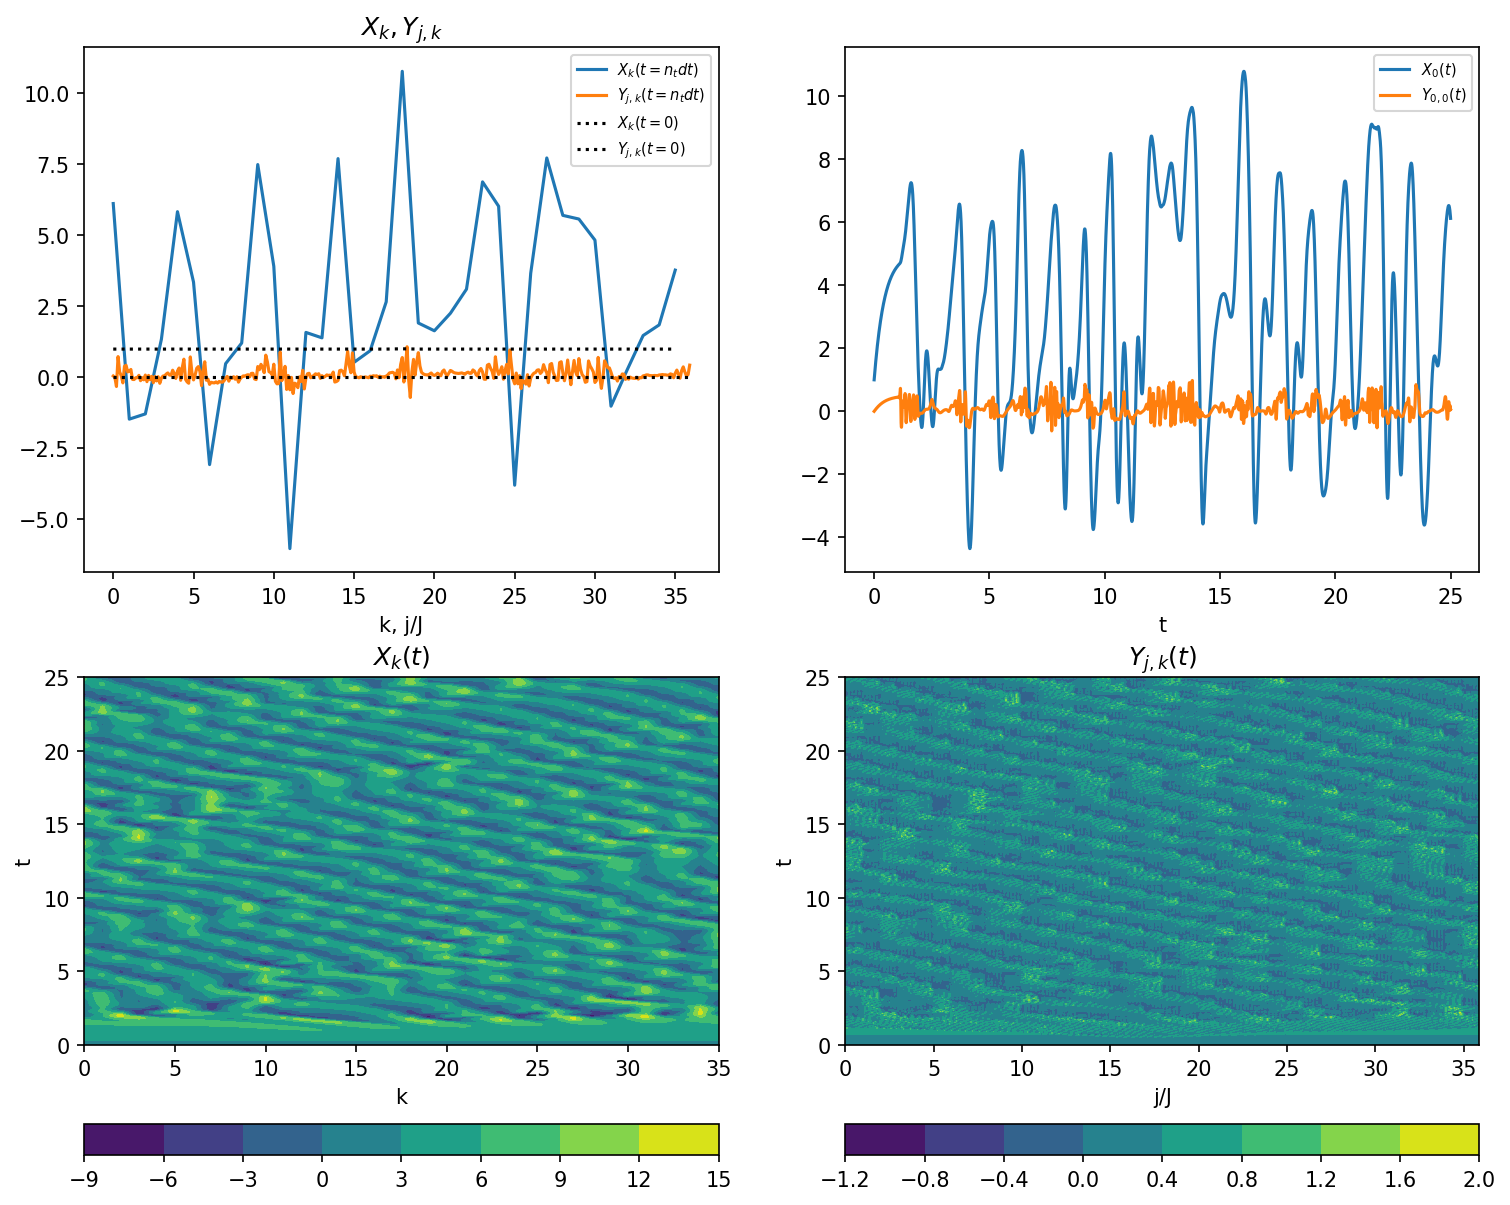

In [ ]:

k = np.arange(K)  # For coordinate in plots
j = np.arange(J * K)  # For coordinate in plots

plt.figure(figsize=(12, 10), dpi=150)
plt.subplot(221)

# Snapshot of X[k]
plt.plot(k, X[-1], label="$X_k(t=n_t dt)$")
plt.plot(j / J, Y[-1], label="$Y_{j,k}(t=n_t dt)$")
plt.plot(k, X_init, "k:", label="$X_k(t=0)$")
plt.plot(j / J, Y_init, "k:", label="$Y_{j,k}(t=0)$")
plt.legend(fontsize=7)
plt.xlabel("k, j/J")
plt.title("$X_k, Y_{j,k}$")
plt.subplot(222)

# Sample time-series X[0](t), Y[0](t)
plt.plot(t, X[:, 0], label="$X_0(t)$")
plt.plot(t, Y[:, 0], label="$Y_{0,0}(t)$")
plt.legend(fontsize=7)
plt.xlabel("t")
plt.subplot(223)

# Full model history of X
plt.contourf(k, t, X)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$")
plt.subplot(224)

# Full model history of Y
plt.contourf(j / J, t, Y)
plt.colorbar(orientation="horizontal")
plt.xlabel("j/J")
plt.ylabel("t")
plt.title("$Y_{j,k}(t)$");

### Two scale model vs single scale model
In practical climate modeling, we rarely have the computational budget to simulate every "fast" variable ($Y$) across the entire globe. Instead, we typically solve a Single-Scale Model (also known as a truncated or Large-Eddy Simulation (LES) model).The Truncated (Single-Scale) EquationIn this simplified version, we only evolve the slow variables $X_k$ and ignore the $Y$ variables entirely. The equation becomes:
\begin{equation}\frac{dt}{dt} X_k =           
\underbrace{- X_{k-1} \left( X_{k-2} - X_{k+1} \right) - X_k + F}_{\text{Resolved Dynamics}} + \underbrace{B_k}_{\text{Unresolved Coupling}}
\end{equation}
where $B_k$ represents the "missing" feedback from the fast scales.

This first experiment is an **unparameterized experiment**, *i.e.*, we set $B_k = 0$. The objective is to evaluate the behavior of the unparameterized system relative to the fully coupled system (the "ground truth"), in order to quantify the physical impact of the missing $Y$ variables.

The evaluation will be based on two diagnostics: the **histogram of the simulated states** and the **power spectral density (PSD)** of the simulations.

# Problem 2: write the single scale OODE
Write the single scale ODE and the numerical integration methods.

In [ ]:
class Lorenz96SingleScale:
    def __init__(self, K=8, J=32, F=20.0, h=1.0, b=10.0, c=10.0, dt=0.005):
        self.K = K
        self.F = F
        self.dt = dt

    def one_scale_deriv(self, X):
        pass

    def rk4_step_1scale(self, X):
        pass

    def generate_filtered(self, X, steps=10000, t0 = 0):
        """Runs the single-scale model and returns X """
        print(f"Generating single-scale data ({steps} steps)...")

        X_hist = [X]
        time = 0 + np.zeros((nt + 1))
        time[0] = t0
        for i in range(steps):
            X = self.rk4_step_1scale(X)
            X_hist.append(X)
            time[i+1] = t0 + self.dt * (i + 1)
        return torch.stack(X_hist), time

We will be instantiating the simulation object and runing the single scale model with the same simulation parameters as the ones used for the two scale model. We will be also using the same initial condition.

In [ ]:
l96_filtered = Lorenz96SingleScale(K=K, F=F, dt=dt)

In [ ]:
X_filtered, t = l96_filtered.generate_filtered(X_init,  steps = nt, t0 = 0)

Generating single-scale data (5000 steps)...


After running the single scale model, we plot the results.

Text(0.5, 1.0, '$X_k(t)$, two scale')

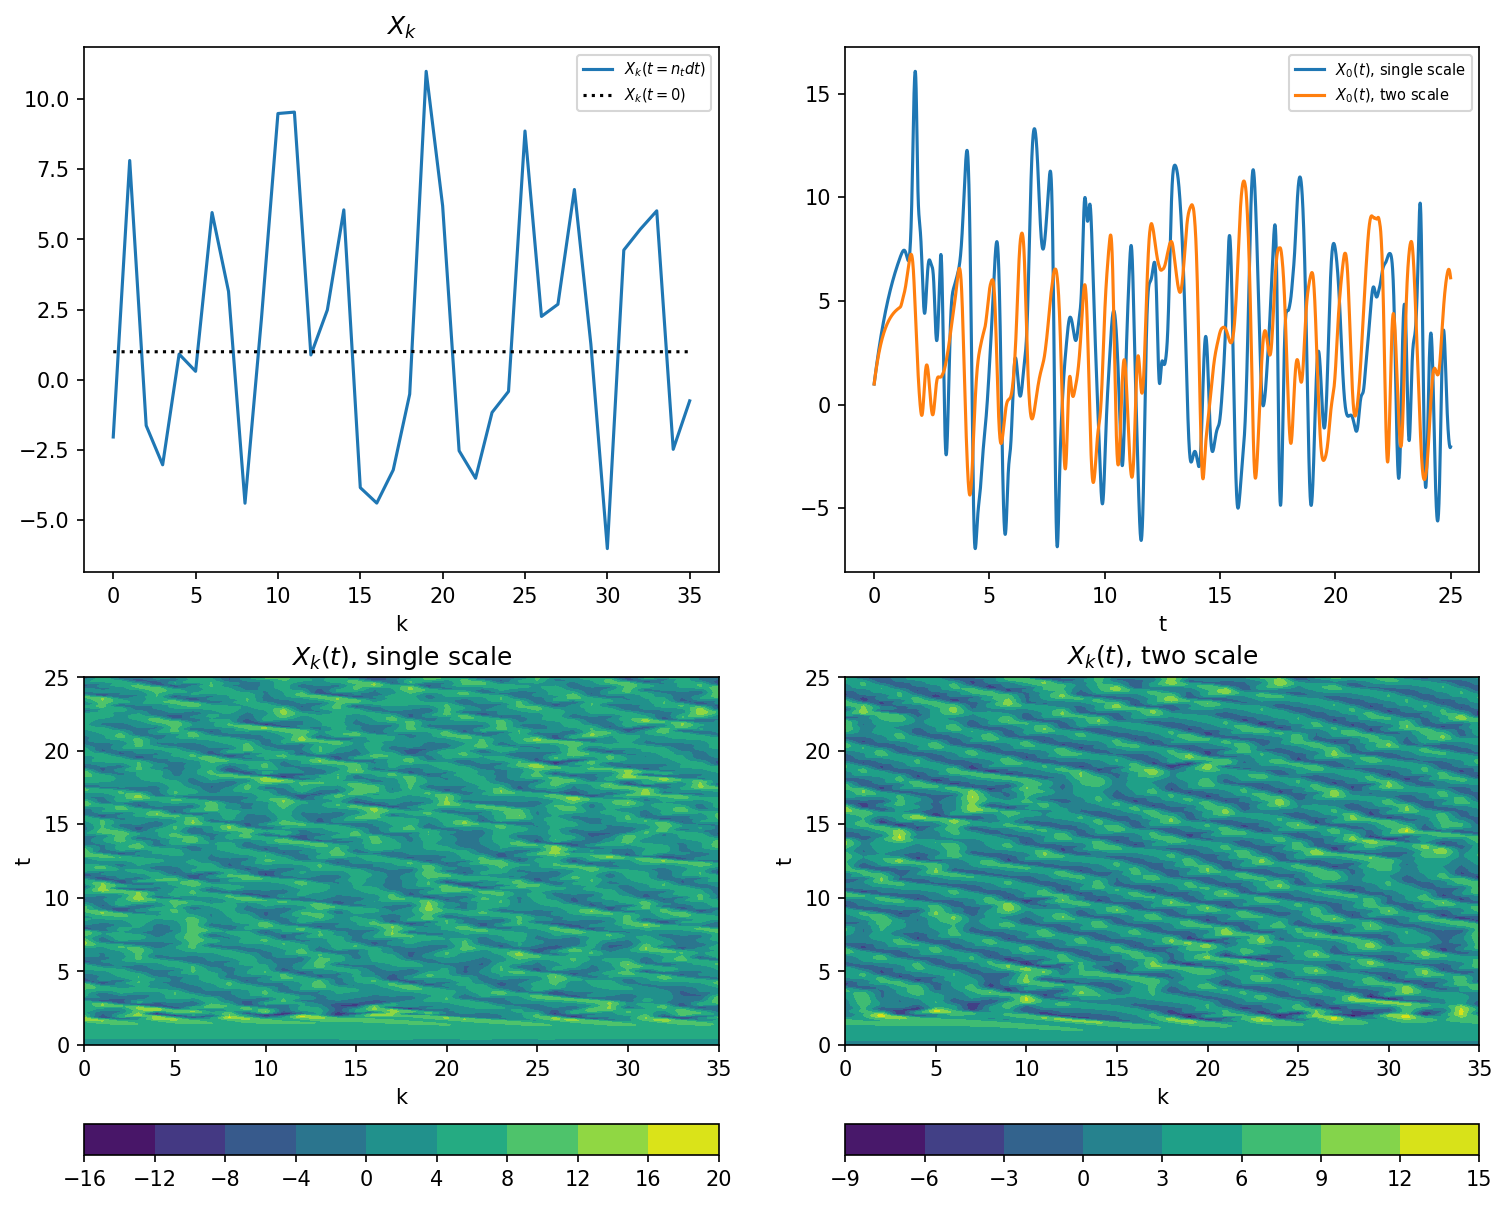

In [ ]:

plt.figure(figsize=(12, 10), dpi=150)
plt.subplot(221)

# Snapshot of X[k]
plt.plot(k, X_filtered[-1], label="$X_k(t=n_t dt)$")
plt.plot(k, X_init, "k:", label="$X_k(t=0)$")
plt.legend(fontsize=7)
plt.xlabel("k")
plt.title("$X_k$")
plt.subplot(222)

# Sample time-series X[0](t), X_filtered[0](t)
plt.plot(t, X_filtered[:, 0], label="$X_0(t)$, single scale")
plt.plot(t, X[:, 0], label="$X_0(t)$, two scale")

plt.legend(fontsize=7)
plt.xlabel("t")
plt.subplot(223)

# Full model history of X_filtered
plt.contourf(k, t, X_filtered)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$, single scale")
plt.subplot(224)

# Full model history of X DNS
plt.contourf(k, t, X)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$, two scale")

We also compare the single-scale model statistics to those of the two-scale model.

<Figure size 1800x750 with 0 Axes>

<Figure size 1800x750 with 0 Axes>

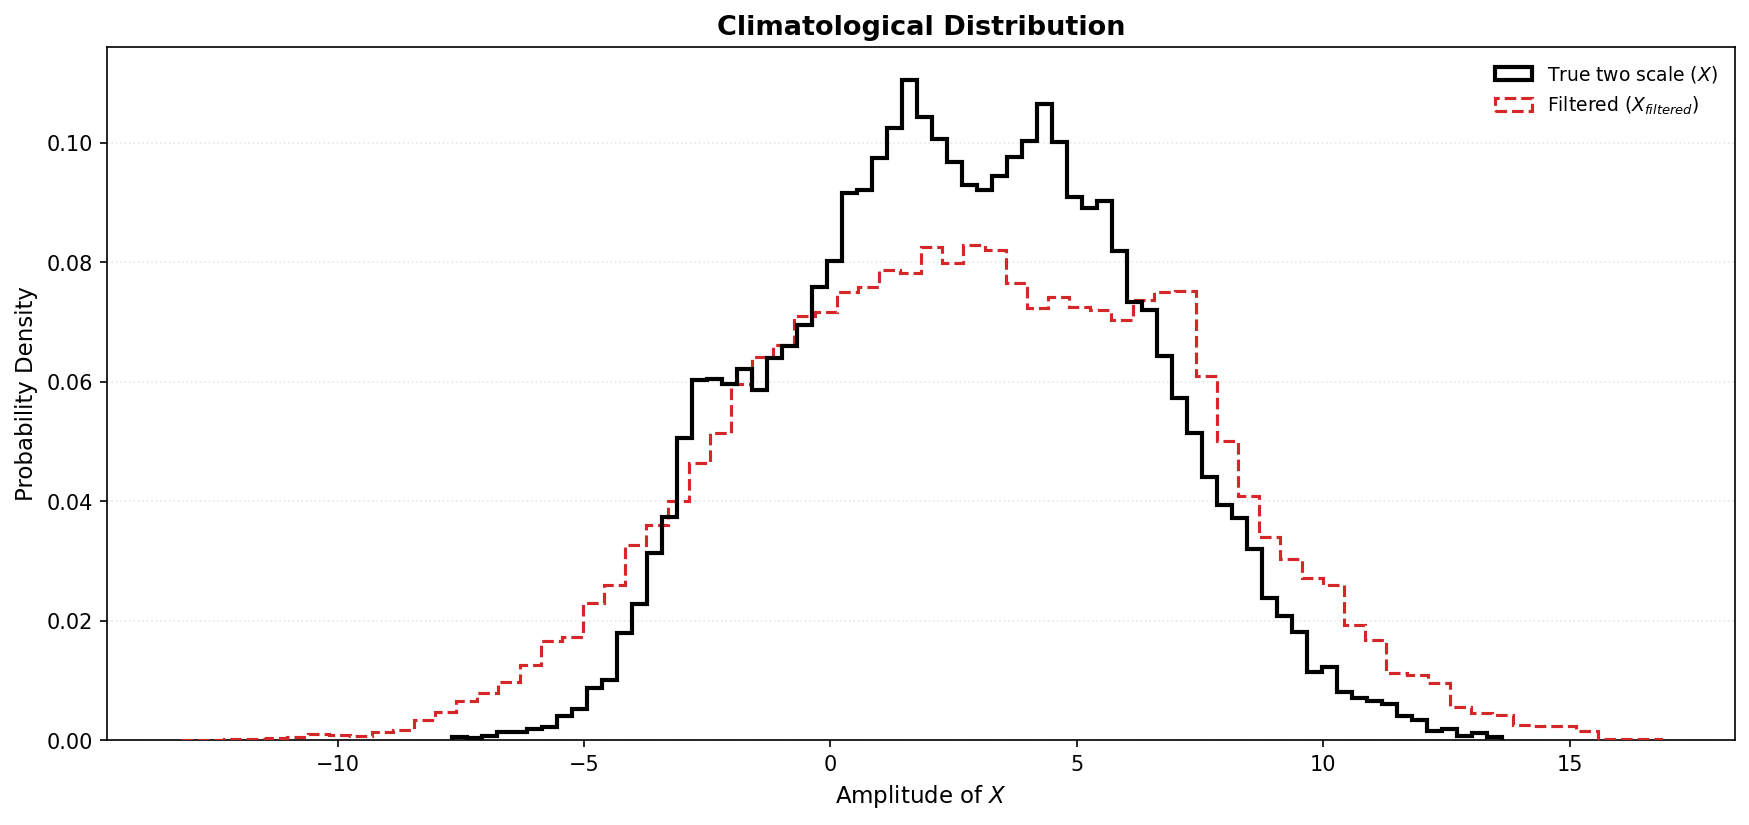

In [ ]:
plt.figure(figsize=(12, 5), dpi=150)

X_flat = X.flatten()
X_filt_flat = X_filtered.flatten()

plt.figure(figsize=(12, 5), dpi=150)

X_flat = X.flatten()

# 1. Setup figure
plt.figure(figsize=(14, 6), dpi=150)

# Style choices: 'step' for outlines of DNS and Filtered, 'stepfilled' for ML models
plt.hist(X.flatten(), bins=70, density=True, histtype='step',
         color='black', linewidth=2, label="True two scale ($X$)", zorder=10)

plt.hist(X_filt_flat, bins=70, density=True, histtype='step',
         color='tab:red', linewidth=1.5, linestyle='--', label="Filtered ($X_{filtered}$)", zorder=5)

plt.xlabel("Amplitude of $X$", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.title("Climatological Distribution", fontsize=13, fontweight='bold')
plt.legend(loc="upper right", frameon=False, fontsize=9)
plt.grid(True, axis='y', alpha=0.3, linestyle=':')
plt.show()

### Offline Learning of the Hybrid Model
In this experiment, we design a hybrid model that is trained offline to reproduce the unresolved coupling term $B_k$. In the offline approach, we treat the parameterization as a supervised regression problem. We do not run the dynamical system during training, instead, we use a pre-computed dataset of "Ground Truth" sub-grid-scale terms.

## The Learning Task
We will be using the data generated from the fully coupled Two-Scale Lorenz-96 system to calculate the true coupling term $C$ at every time step:
\begin{equation}
C_k = -\left( \frac{hc}{b} \right) \sum_{j=0}^{J-1} Y_{j,k}
\end{equation}

Our goal then is to train a Multi-Layer Perceptron (MLP) to learn the mapping:

\begin{equation}
\hat{C}_k = {NN}(X_k; \theta)
\end{equation}

where $X_k$ is the state of the resolved variables and $\hat{C}_k$ is the predicted coupling.

## The cost function
The term "offline" refers to the fact that the Neural Network is isolated from the Differential Equation solver during the training process.


Loss Function: We minimize the Mean Squared Error (MSE) between the true coupling and the predicted coupling.$$\mathcal{L}_{offline} = \frac{1}{N} \sum_

*   Input: Snapshots of $X$ from the DNS.
*   Target: Corresponding values of $C$ from the DNS.
*   Loss Function: We minimize the Mean Squared Error (MSE) between the true coupling and the predicted coupling.$${L}_{offline} = \frac{1}{N} \sum_{i=1}^{N} \| C_i - \hat{C}_i \|^2$$

Once the model is trained, we will "plug it back in" to the Single-Scale equations to see if it can restore the system's statistics.

In order to implement the training of the NN model we need to the process the data as follows:

**Data Preparation and Batching**

*Spin-up Removal:* We discard the first 2000 samples. This "spin-up" period allows the chaotic system to move away from its artificial initial conditions and settle onto its natural physical attractor.

*Dataset Construction:* Using TensorDataset, we map each resolved state $X_t$ (the input) to its corresponding unresolved coupling $C_t$ (the target). This creates a supervised learning pair for every time step.

*Train/Validation Split:* We divide the data into training and validation sets(80% training, 20% validation) to monitor overfiting.

*Assembling the DataLoaders:* The DataLoader manages the training process by breaking the data into batches of 256.

#Problem 3: Offline learning
Here you should define a neural network
\begin{equation}
\hat{C}_k = {NN}(X_k; \theta)
\end{equation}
that takes as inputs the slow variables and outputs the coupling term. In order to train this netwrok, you will need to bo back to the multiscale model and generate training data. The training data are pairs of slow variables/coupling term 𝑋𝑘,C𝑘.

Hint: make the RK4 integrator return C_k. the numerical integration of the two scale model will return the pairs of slow variables/coupling term 𝑋𝑘,C𝑘. You should modify the data_generation function accordingly as follow:


```
    def generate_dns(self, X, Y, steps=10000, t0=0):
        """
        Runs the simulation for a specified number of steps.
        Returns the history of X, Y, and the true coupling term C over time.
        """
        print(f"Generating two scale Lorenz 96 data ({steps} steps)...")

        X_hist, Y_hist, C_hist = [X], [Y], []
        # Pre-allocate time array using numpy
        time = t0 + np.zeros((steps + 1))

        for i in range(steps):
            # Integrate one time step
            X, Y, C = self.rk4_step_2scale(X, Y)

            # Store results
            X_hist.append(X)
            Y_hist.append(Y)
            C_hist.append(C)
            time[i+1] = t0 + self.dt * (i + 1)

        # Convert lists of tensors into high-dimensional tensors [Time, Variables]
        return torch.stack(X_hist), torch.stack(Y_hist), torch.stack(C_hist), time
```

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, random_split
spinup_sampels = 2000
input_data = X[spinup_sampels:-1]
target_data = C[spinup_sampels:]
# Assuming X and C are already PyTorch tensors of shape [num_samples, K]
dataset = TensorDataset(input_data, target_data)

# Calculate split sizes (80% Train, 20% Validation)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

# Split the dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class MLParameterization(torch.nn.Module):
    def __init__(self, K=8, hidden_size=64):
        super().__init__()
        # Define individual layers explicitly
        self.fc1 = torch.nn.Linear(K, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, K)

    def forward(self, x):
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
hidden_size = 64
model = MLParameterization(K=K, hidden_size=hidden_size)

In [ ]:
model

MLParameterization(
  (fc1): Linear(in_features=36, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=36, bias=True)
)

In [ ]:
# 1. Set Hyperparameters
epochs = 100
lr = 0.01

# 2. Define Loss and Optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# 3. Initialize lists to track progress
train_losses = []
val_losses = []

print("Starting Training...")

# 4. The Main Training Loop
for epoch in range(epochs):

    # --- TRAINING PHASE ---
    model.train()  # Tell PyTorch we are in training mode
    running_train_loss = 0.0

    for batch_X, batch_C in train_loader:
        optimizer.zero_grad()  # Clear old gradients

        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_C)

        # Backward pass (calculate gradients)
        loss.backward()

        # Optimize (update weights)
        optimizer.step()

        running_train_loss += loss.item() * batch_X.size(0)

    # Calculate average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()  # Tell PyTorch we are in evaluation mode
    running_val_loss = 0.0

    with torch.no_grad():  # Turn off gradients to save memory and speed up
        for batch_X, batch_C in val_loader:
            predictions = model(batch_X)
            val_loss = criterion(predictions, batch_C)

            running_val_loss += val_loss.item() * batch_X.size(0)

    # Calculate average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    # Print progress every 10 epochs (and the first one)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Starting Training...
Epoch [  1/100] | Train Loss: 1.5708 | Val Loss: 0.9886
Epoch [ 10/100] | Train Loss: 0.1922 | Val Loss: 0.1932
Epoch [ 20/100] | Train Loss: 0.1346 | Val Loss: 0.1426
Epoch [ 30/100] | Train Loss: 0.1161 | Val Loss: 0.1231
Epoch [ 40/100] | Train Loss: 0.1072 | Val Loss: 0.1239
Epoch [ 50/100] | Train Loss: 0.1003 | Val Loss: 0.1087
Epoch [ 60/100] | Train Loss: 0.0957 | Val Loss: 0.1072
Epoch [ 70/100] | Train Loss: 0.0909 | Val Loss: 0.1021
Epoch [ 80/100] | Train Loss: 0.0907 | Val Loss: 0.0995
Epoch [ 90/100] | Train Loss: 0.0894 | Val Loss: 0.1010
Epoch [100/100] | Train Loss: 0.0853 | Val Loss: 0.0945


In [ ]:
# Plot trainig and validation losses

Once the model is trained and validated, we run it online, i.e., coupled with the single-scale model:
\begin{equation}
\frac{d X_k}{dt} =
\underbrace{- X_{k-1} \left( X_{k-2} - X_{k+1} \right) - X_k + F}_{\text{Resolved dynamics}}
+
\underbrace{NN(X_k)}_{\text{Neural model}}.
\end{equation}

# Problem 4: Online performance of the trained model,
Here we will be building the hybrid model, the task is to plug the NN correction term into the Lorenz single scale model.

In [ ]:
class HybridLorenz96Offline:
    def __init__(self, model, K=8, J=32, F=20.0, h=1.0, b=10.0, c=10.0, dt=0.005):
        self.K = K
        self.F = F
        self.dt = dt
        self.model = model

    def one_scale_deriv(self, X):
        """Calculates the time derivative for the 1-scale problem (LES)."""
        # single scale model with NN correction
        pass

    def rk4_step_1scale(self, X):
        """4th-order Runge-Kutta stepper for the one-scale (LES) model."""
        pass

    def generate_hybrid(self, X, steps=10000, t0 = 0):
        """Runs the single-scale model and returns X """
        print(f"Generating single-scale data ({steps} steps)...")

        X_hist = [X]
        time = 0 + np.zeros((nt + 1))
        time[0] = t0
        for i in range(steps):
            X = self.rk4_step_1scale(X)
            X_hist.append(X)
            time[i+1] = t0 + self.dt * (i + 1)
        return torch.stack(X_hist), time

We run the model with the same parameters, but with an NN-based neural correction

In [ ]:
l96_hybrid_offline = HybridLorenz96Offline(model = model, K=K, F=F, dt=dt)

In [ ]:
X_hybrid_offline, t = l96_hybrid_offline.generate_hybrid(X_init,  steps = nt, t0 = 0)

Generating single-scale data (5000 steps)...


<Figure size 1800x750 with 0 Axes>

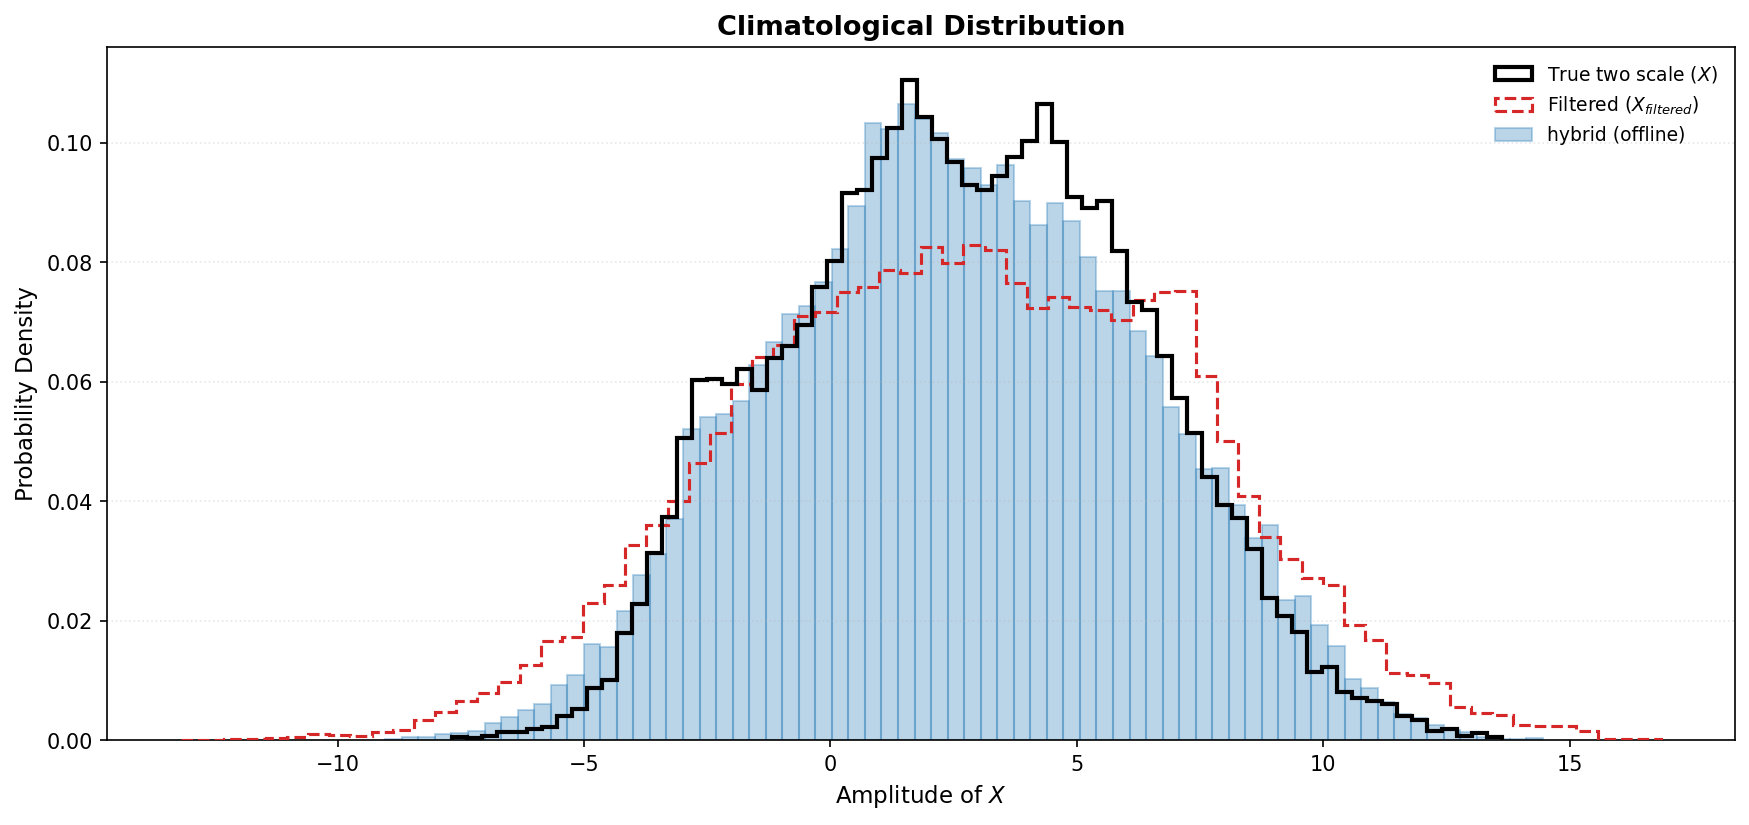

In [ ]:
plt.figure(figsize=(12, 5), dpi=150)

X_hyb_flat_offline = X_hybrid_offline.flatten()

# 1. Setup figure
plt.figure(figsize=(14, 6), dpi=150)

# Style choices: 'step' for outlines of DNS and Filtered, 'stepfilled' for ML models
plt.hist(X.flatten(), bins=70, density=True, histtype='step',
         color='black', linewidth=2, label="True two scale ($X$)", zorder=10)

plt.hist(X_filt_flat, bins=70, density=True, histtype='step',
         color='tab:red', linewidth=1.5, linestyle='--', label="Filtered ($X_{filtered}$)", zorder=5)

plt.hist(X_hyb_flat_offline, bins=70, density=True, alpha=0.3,
         color='tab:blue', edgecolor='tab:blue', label="hybrid (offline)")
plt.xlabel("Amplitude of $X$", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.title("Climatological Distribution", fontsize=13, fontweight='bold')
plt.legend(loc="upper right", frameon=False, fontsize=9)
plt.grid(True, axis='y', alpha=0.3, linestyle=':')
plt.show()

### Problem 5: Online learning for trainig the hybrid model
In this experiment, we shift from offline learning to Online Learning. While the offline approach ensures the model can predict the coupling term $C$ at a single instant, it does not guarantee that the resulting dynamical system will be stable or physically accurate over time.
**Differentiable Physics and Time-Unrolling**
In the online approach, we embed the Neural Network directly into the Numerical right-hand-side of the equations used by the numerical solver (RK4). Instead of minimizing the error of the coupling term $C$ itself, we minimize the Trajectory Error. We choose a Control Window of $N$ steps. Starting from an initial condition $X(t)$, the model predicts the entire evolution of the system up to $X(t+N)$.
**The Learning Task**
The loss function is calculated by comparing the predicted trajectory against the "Ground Truth" DNS trajectory over the entire window:

\begin{equation}
{L}_{online} = \frac{1}{N} \sum_{n=1}^{N} \| X_{DNS}(t+n) - \hat{X}_{hybrid}(t+n) \|^2
\end{equation}

To update the weights, PyTorch must backpropagate the gradients through the RK4 solver steps. This forces the Neural Network to learn not just the instantaneous forcing, but how that forcing interacts with the nonlinear dynamics.

In online learning, the physical model and its numerical solver must be differentiable in order to compute gradients (using backpropagation) through the physical simulation. To achieve this, we implement the Lorenz--96 model in a differentiable framework (here PyTorch). This requires the following modifications to the HybridLorenz96 class:

* The class must inherit from torch.nn.Module, so that PyTorch can automatically register the model parameters and compute gradients during backpropagation.
* The rhs function should handle both batched and non-batched inputs.
* The generate_hybrid function should also handle both batched and non-batched inputs.

In [ ]:
class HybridLorenz96Online(torch.nn.Module):
    def __init__(self, hidden_size, K=8, J=32, F=20.0, h=1.0, b=10.0, c=10.0, dt=0.005):
        super().__init__()
        self.K = K
        self.F = F
        self.dt = dt
        self.fc1 = torch.nn.Linear(K, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, K)

    def model(self, x):
        # Pass data through layer 1, then apply activation
        x = torch.nn.functional.relu(self.fc1(x))

        # Pass data through layer 2, then apply activation
        x = torch.nn.functional.relu(self.fc2(x))

        # Pass data through final output layer (no activation for regression)
        x = self.fc3(x)

        return x

    def one_scale_deriv(self, X, train = False):
        # define here the hybrid model
        pass

    def rk4_step_1scale(self, X, train = False):
        """4th-order Runge-Kutta stepper for the one-scale (LES) model."""
        pass

    def generate_hybrid(self, X, steps, t0 = 0, train=False):
          """Runs the single-scale model for N steps and returns the trajectory."""
          X_hist = [X]
          time = 0 + torch.zeros((nt + 1))
          for i in range(steps):
              X = self.rk4_step_1scale(X, train=train)
              X_hist.append(X)
              time[i+1] = t0 + self.dt * (i + 1)
          # Stack along dimension 1 so the output shape is [Batch, Steps, K]
          return torch.stack(X_hist, dim=1), time

**Data Preparation and Batching in online learning**

* Spin-up Removal: same as for offline learning.

* Dataset Construction: using TensorDataset, we map each resolved state $X_{t_0}$ (the input) to its future evolution over a control window of $N$ steps. This creates a supervised learning pair for every time step.

* Train/Validation Split: we divide the data into training and validation sets (80\% training, 20\% validation) to monitor overfitting.

* Assembling the DataLoaders: the DataLoader manages the training process by breaking the data into batches of 256 samples.

In [ ]:
# Let's say we want a control window of N=10 steps
N_window = 10

# 1. Calculate how many valid windows we can extract
num_windows = len(input_data) - N_window

# 2. Extract the initial conditions (everything except the very end)
X_inits = input_data[:num_windows]

# 3. Build the targets (the N future steps for each initial condition)
target_list = []
for i in range(num_windows):
    target_list.append(input_data[i+1 : i+1+N_window])

X_targets = torch.stack(target_list) # Shape becomes [num_windows, N_window, K]

# 4. Create Full Dataset and Split
dataset = TensorDataset(X_inits, X_targets)

val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 5. Create DataLoaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)



In [ ]:
hybrid_model_online = HybridLorenz96Online(hidden_size=64, K=K, F=F, dt=dt)
optimizer = torch.optim.Adam(hybrid_model_online.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

epochs = 100
train_losses = []
val_losses = []

print(f"Starting Online Training (Unrolling {N_window} steps)...")

for epoch in range(epochs):

    # ==========================
    #      TRAINING PHASE
    # ==========================
    hybrid_model_online.train()
    running_train_loss = 0.0

    for batch_X_init, batch_X_targets in train_loader:
        optimizer.zero_grad()

        # Unroll the solver (train=True so gradients are tracked)
        predicted_trajectory, _ = hybrid_model_online.generate_hybrid(batch_X_init, steps=N_window, train=True)
        loss = criterion(predicted_trajectory[:,1:,:], batch_X_targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model_online.parameters(), max_norm=1.0)
        optimizer.step()

        running_train_loss += loss.item() * batch_X_init.size(0)

    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ==========================
    #     VALIDATION PHASE
    # ==========================
    hybrid_model_online.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch_X_init, batch_X_targets in val_loader:

            # Unroll the solver (train=False for evaluation)
            predicted_trajectory, _ = hybrid_model_online.generate_hybrid(batch_X_init, steps=N_window, train=False)

            loss = criterion(predicted_trajectory[:,1:,:], batch_X_targets)
            running_val_loss += loss.item() * batch_X_init.size(0)

    avg_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    # Print progress
    print(f"Epoch [{epoch+1:2d}/{epochs}] | Train MSE: {avg_train_loss:.5f} | Val MSE: {avg_val_loss:.5f}")

Starting Online Training (Unrolling 10 steps)...
Epoch [ 1/100] | Train MSE: 0.00217 | Val MSE: 0.00172
Epoch [ 2/100] | Train MSE: 0.00153 | Val MSE: 0.00129
Epoch [ 3/100] | Train MSE: 0.00119 | Val MSE: 0.00106
Epoch [ 4/100] | Train MSE: 0.00097 | Val MSE: 0.00087
Epoch [ 5/100] | Train MSE: 0.00081 | Val MSE: 0.00073
Epoch [ 6/100] | Train MSE: 0.00069 | Val MSE: 0.00063
Epoch [ 7/100] | Train MSE: 0.00059 | Val MSE: 0.00055
Epoch [ 8/100] | Train MSE: 0.00051 | Val MSE: 0.00048
Epoch [ 9/100] | Train MSE: 0.00045 | Val MSE: 0.00042
Epoch [10/100] | Train MSE: 0.00040 | Val MSE: 0.00038
Epoch [11/100] | Train MSE: 0.00035 | Val MSE: 0.00034
Epoch [12/100] | Train MSE: 0.00032 | Val MSE: 0.00031
Epoch [13/100] | Train MSE: 0.00029 | Val MSE: 0.00029
Epoch [14/100] | Train MSE: 0.00027 | Val MSE: 0.00027
Epoch [15/100] | Train MSE: 0.00026 | Val MSE: 0.00026
Epoch [16/100] | Train MSE: 0.00024 | Val MSE: 0.00025
Epoch [17/100] | Train MSE: 0.00023 | Val MSE: 0.00024
Epoch [18/100] |

In [ ]:
with torch.no_grad():
  X_hybrid_online, t = hybrid_model_online.generate_hybrid(X_init,  steps = nt, t0 = 0, train = False)

In [ ]:
X_hyb_flat_online = X_hybrid_online.flatten()

plt.figure(figsize=(14, 6), dpi=150)

# Style choices: 'step' for outlines of DNS and Filtered, 'stepfilled' for ML models
plt.hist(X.flatten(), bins=70, density=True, histtype='step',
         color='black', linewidth=2, label="True two scale ($X$)", zorder=10)

plt.hist(X_filt_flat, bins=70, density=True, histtype='step',
         color='tab:red', linewidth=1.5, linestyle='--', label="Filtered ($X_{filtered}$)", zorder=5)

plt.hist(X_hyb_flat_offline, bins=70, density=True, alpha=0.3,
         color='tab:blue', edgecolor='tab:blue', label="hybrid (offline)")

plt.hist(X_hyb_flat_online, bins=70, density=True, alpha=0.4,
         color='tab:orange', edgecolor='tab:orange', label="hybrid (online)")

plt.xlabel("Amplitude of $X$", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.title("Climatological Distribution", fontsize=13, fontweight='bold')
plt.legend(loc="upper right", frameon=False, fontsize=9)
plt.grid(True, axis='y', alpha=0.3, linestyle=':')
plt.show()